In [1]:
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error, mean_absolute_error
from IPython.display import clear_output
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [2]:
torch.cuda.is_available()

True

In [3]:
from dotenv import load_dotenv
from pydantic_settings import BaseSettings

load_dotenv()


class Secrets(BaseSettings):
    db_user: str
    db_password: str
    db_host: str
    db_port: str
    db_name: str
    db_table_raw_meat: str

    class Config:
        env_file = ".env"
        env_file_encoding = "utf-8"


secrets = Secrets()

In [4]:
url = f'mysql+pymysql://{secrets.db_user}:{secrets.db_password}@{secrets.db_host}:{secrets.db_port}/{secrets.db_name}'

engine = create_engine(url)
with engine.connect() as conn:
    df_db = pd.read_sql(
        f'''
        SELECT *
        FROM {secrets.db_table_raw_meat}
        WHERE date >= '2020-01-01'
        AND product in ('Говядина')
        ''',
        conn,
        index_col='id'
    )

In [5]:
date_range_df = pd.DataFrame(pd.date_range(start='01-01-2020', end='22-01-2025', freq='1d'), columns=['ds'])

# добавление макро показателей
macro_df = pd.read_csv('macroeconomic_indicators.csv', encoding='utf-8')

cols = ['ВВП','Индекс пром.производства','Цены производителей пром.товаров','Производство пищевых продуктов','Инфляция','Индекс реальной зарплаты']
for col in cols:
    macro_df[col] = macro_df[col].apply(lambda x: float(x[:-1].replace(',', '.')))

macro_df['ds'] = pd.to_datetime(macro_df['ds'], yearfirst=False, dayfirst=True)
macro_df = pd.merge(date_range_df, macro_df, on='ds', how='left').ffill()

# добавление курса рубля к доллару
df_rub = pd.read_csv('rub_dollar_course.csv', encoding='windows-1251')
df_rub['data'] = pd.to_datetime(df_rub['data'])
df_rub = df_rub.drop(['nominal', 'cdx'], axis=1)
df_rub.rename(columns={'data':'ds'}, inplace=True)
df_rub = pd.merge(date_range_df, df_rub, on='ds', how='left').ffill().bfill()
df_rub['curs'] = df_rub['curs'].apply(lambda x:float(x.replace(',', '.')))

In [7]:
df_db

,category,region,product,description,temperature_state,country,packaging,availability,batch,delivery_terms,...,city,date,product_type,sort,certification,federal_okrug,updated_at,week_number,file_name,hash_value
id,,,,,,,,,,,,,,,,,,,,,
2725,Мясо и мясопродукты,None,Говядина,аорта,зам,Россия,None,склад,"от кор. до 1,5 тонн",самовывоз,...,None,2024-10-31,аорта,None,None,ПФО,2024-12-25 04:48:17,44,PFO_Meat__31.10.2024.xls,3a58bf51e39451f203f6503e9a2f2c105257e02604926d...
3083,Мясо и мясопродукты,None,Говядина,печень 1 сорт,зам,Парагвай,коробки,склад,"от кор. до 1,5 тонн",самовывоз,...,None,2024-10-31,печень,1 сорт,None,ПФО,2024-12-25 04:48:17,44,PFO_Meat__31.10.2024.xls,9b54e050c56e3a2ea2cc260640338710bf8f31b0f0a93b...
3084,Мясо и мясопродукты,None,Говядина,печень 1 сорт,зам,None,None,None,None,None,...,None,2024-10-31,печень,1 сорт,None,ПФО,2024-12-25 04:48:17,44,PFO_Meat__31.10.2024.xls,cca063f5a2f8e4799f99fdf2a4c2ccb11173c2441c153f...
3085,Мясо и мясопродукты,None,Говядина,печень 2 кат.,зам,Россия,None,склад,"от кор. до 1,5 тонн",самовывоз,...,None,2024-10-31,печень,2 сорт,None,ПФО,2024-12-25 04:48:17,44,PFO_Meat__31.10.2024.xls,016c190a458df054a2f0b13d48aa2eeeb389b3449686c5...
3086,Мясо и мясопродукты,None,Говядина,печень,зам,None,1,None,None,None,...,None,2024-10-31,печень,None,None,ПФО,2024-12-25 04:48:17,44,PFO_Meat__31.10.2024.xls,7248fa095c6ff867fec2c6b8394bafc0a820767a112c32...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7036626,Мясо и мясопродукты,None,Говядина,язык гост,зам,Россия,инд. 18-20 кг.,склад,"от 1,5 до 3 тонн",самовывоз,...,None,2025-02-12,язык,None,гост,Москва,2025-02-12 13:27:31,7,Moscow_Meat_12.02.2025.xls,4c2346bda46c11dae314df48e3b5225c88be6eaf29ae84...
7036627,Мясо и мясопродукты,None,Говядина,язык Offal,зам,Аргентина,инд.,склад,None,None,...,None,2025-02-12,язык,None,None,Москва,2025-02-12 13:27:31,7,Moscow_Meat_12.02.2025.xls,bace6e4353b9179825c4722d9f676464bb10398d39a111...
7036628,Мясо и мясопродукты,None,Говядина,язык,зам,Бразилия,инд.,склад,None,None,...,None,2025-02-12,язык,None,None,Москва,2025-02-12 13:27:31,7,Moscow_Meat_12.02.2025.xls,bf3349f66c4a25d6c6b6bf447f21cd37d3e2cfdef26d76...


In [ ]:
df_data = df_db.copy()

beef_product_types = ['азу','антрекот','аорта','балык','бедро','Бескостная','бефстроганов','бифштекс','Блочная','вымя','вырезка','глазной мускул','головы','голяшка','грудинка','грудной отруб','губы','гуляш','диафрагма','длиннейшая мышца','железа','желудки','жилка','жир','жир (сырец)','задние части','илей','калтык','карбонад','кишка','книжка','копыта','кострец','кость','легкое','лопатка','лопаточно-плечевая часть','лопаточная часть','лытка','медальон','мозги','мука мясокостная','мышца','мякоть','мясо','набор для гуляша','набор для супа','набор для тушения','набор для холодца','ноги','нос','обрезь','обрезь головная','огузок','Односортная','оковалок','окорок','отруб реберный','отруб шейный','пашина','пенис','передние части','передние четверти','печень','подбедерок','поджарка','подлопаточная часть','полутуши','почки','путовый сустав','рагу','ребро','рубец','рулька','селезенка','семенники','сердце','соединительная ткань','спинно-поясничный отруб','стейк','Субпродукты','суставы','сухожилия','сычуг','тазобедренный отруб','тонкий край','трахея','тримминг','туши','уши','фарш','филе','филей','хвосты','хрящи','черева','четверти','шейная часть','шейно-лопаточный отруб','шейный отруб','шея','шкура','шпик','шпик боковой','щека','язык']
df_data = df_data[df_data['product_type'].isin(beef_product_types)]

group = df_data.groupby('product_type').count().sort_values('category', ascending=False)
categories = group[group['category'] > 5000].index.to_list()
df_data = df_data[df_data['product_type'].isin(categories)]
df_data = df_data[['product', 'product_type', 'date', 'price', ]]
df_data.sort_values('date', ascending=True, inplace=True)
df_data.rename(columns={'date':'ds'}, inplace=True)

In [9]:
g = df_data.groupby(['ds', 'product', 'product_type']).mean('price')

prophet_df = g.reset_index()
prophet_df['ID'] = prophet_df['product'] + ' ' + prophet_df['product_type']
prophet_df.drop(['product', 'product_type'], axis=1, inplace=True)
const_g = prophet_df.groupby('ID').nunique('price')
prophet_df.drop(prophet_df[prophet_df['ID'].isin(const_g[const_g['price'] < 3].index.to_list())].index, axis=0, inplace=True)

In [10]:
nd = len(date_range_df)
nu = len(prophet_df['ID'].unique())

df_final = pd.DataFrame(
    {
        'ID': prophet_df['ID'].unique().tolist() * nd,
        'ds': np.repeat(date_range_df, nu)
    }
)
df_final = df_final.merge(prophet_df, how='left')

In [11]:
df = pd.merge(df_final, macro_df, on='ds', how='left')
df = pd.merge(df, df_rub, on='ds', how='left')

In [12]:
df.rename(columns={'price':'y'}, inplace=True)

In [13]:
for cat in df['ID'].unique().tolist():
    df_ = df[df['ID'] == cat].interpolate('linear', limit_direction='both')
    df.loc[df_.index, 'y'] = df_['y']

In [14]:
df = df[['ID', 'ds', 'ВВП', 'Индекс пром.производства',
       'Цены производителей пром.товаров', 'Производство пищевых продуктов',
       'Инфляция', 'Индекс реальной зарплаты', 'curs', 'y']]

In [15]:
cats_name = df['ID'].unique().tolist()
len(cats_name)

24

In [16]:
cat = cats_name[0]
df_ = df[df['ID'] == cat]
df_ = df_.rename(columns={'y': cat})

for cat in cats_name[1:]:
    df_ =  pd.merge(df_, df[df['ID'] == cat][['ds', 'y']].rename(columns={'y': cat}), on='ds') 

In [17]:
df = df_.copy()
df.head(2)

,ID,ds,ВВП,Индекс пром.производства,Цены производителей пром.товаров,Производство пищевых продуктов,Инфляция,Индекс реальной зарплаты,curs,Говядина вырезка,...,Говядина полутуши,Говядина рубец,Говядина сердце,Говядина спинно-поясничный отруб,Говядина тазобедренный отруб,Говядина тримминг,Говядина фарш,Говядина щека,Говядина язык,Говядина ноги
0,Говядина вырезка,2020-01-01,1.6,1.5,1.2,2.7,2.42,6.5,61.9057,847.24,...,254.727273,80.0,140.111111,321.526316,367.5,216.16092,240.75,265.555556,362.778378,78.4625
1,Говядина вырезка,2020-01-02,1.6,1.5,1.2,2.7,2.42,6.5,61.9057,847.24,...,254.727273,80.0,140.111111,321.526316,367.5,216.16092,240.75,265.555556,362.778378,78.4625


In [18]:
df.reset_index(drop=True, inplace=True)

In [19]:
df.drop('ID', axis=1, inplace=True)
df.set_index('ds', inplace=True)

In [20]:
df.head(1)

,ВВП,Индекс пром.производства,Цены производителей пром.товаров,Производство пищевых продуктов,Инфляция,Индекс реальной зарплаты,curs,Говядина вырезка,Говядина глазной мускул,Говядина голяшка,...,Говядина полутуши,Говядина рубец,Говядина сердце,Говядина спинно-поясничный отруб,Говядина тазобедренный отруб,Говядина тримминг,Говядина фарш,Говядина щека,Говядина язык,Говядина ноги
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,1.6,1.5,1.2,2.7,2.42,6.5,61.9057,847.24,419.625,296.368421,...,254.727273,80.0,140.111111,321.526316,367.5,216.16092,240.75,265.555556,362.778378,78.4625


# LSTM

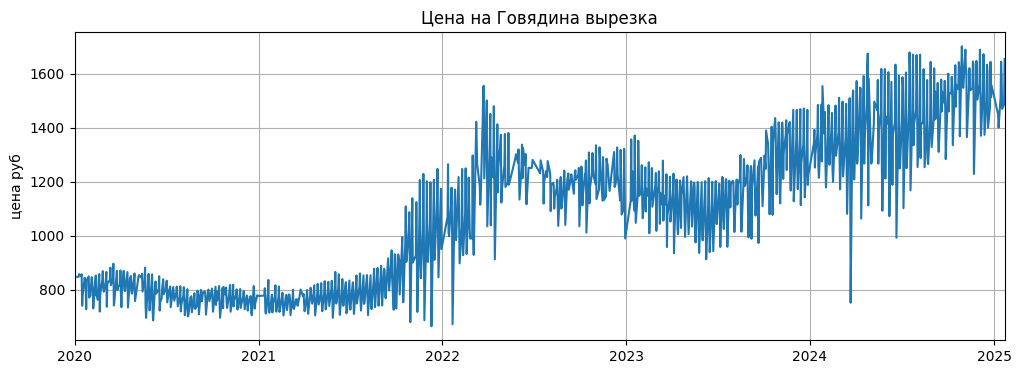

In [21]:
plt.figure(figsize = (12,4))
plt.title('Цена на Говядина вырезка')
plt.ylabel('цена руб')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df.index, df['Говядина вырезка'])
plt.show()

In [22]:
thr = int(len(df) * 0.8)
train_df, test_df = df[:thr], df[thr:]
len(train_df), len(test_df)

(1479, 370)

In [23]:
from sklearn.preprocessing import MinMaxScaler

economic_columns = ['ВВП', 'Индекс пром.производства', 'Цены производителей пром.товаров', 'Производство пищевых продуктов', 'Инфляция', 'Индекс реальной зарплаты', 'curs']

# instantiate a scaler
scaler_data = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

# normalize the training set
data_norm = scaler_data.fit_transform(train_df[economic_columns])
y_norm = scaler_y.fit_transform(train_df[cats_name])
train_norm = torch.FloatTensor(np.concatenate((data_norm, y_norm), axis=1))

# normalize the test set
data_norm = scaler_data.transform(test_df[economic_columns])
y_norm = scaler_y.transform(test_df[cats_name])
test_norm = torch.FloatTensor(np.concatenate((data_norm, y_norm), axis=1))

In [24]:
len(df.columns)

31

In [25]:
window_size = 90
input_size = len(df.columns)
output_size = len(df.columns) - len(economic_columns)

# define a function to create sequence/label tuples
def input_data(seq,ws):
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1][:, -output_size:]
        out.append((window, label))
    return out

# apply input_data to train_norm
train_data = input_data(train_norm, window_size)
test_data = input_data(test_norm, window_size)
len(train_data), len(test_data)

(1389, 280)

In [26]:
import torch.nn as nn

class LSTMnetwork(nn.Module):
    def __init__(self,input_size=input_size, hidden_size=512, output_size=output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, dropout=0.0, bidirectional=True)
        self.linear = nn.Linear(hidden_size*2, output_size)
        self.hidden = (torch.zeros(2, 1,self.hidden_size).to('cuda'),
                       torch.zeros(2, 1,self.hidden_size).to('cuda'))

    def forward(self, seq):
        lstm_out, _ = self.lstm(seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq), -1))
        return pred[-1]

In [27]:
torch.manual_seed(42)

model = LSTMnetwork()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.to('cuda')

LSTMnetwork(
  (lstm): LSTM(31, 512, bidirectional=True)
  (linear): Linear(in_features=1024, out_features=24, bias=True)
)

In [28]:
def train(model, data, optimizer, loss_fn):
    model.train()
    loss_batch = []
    for seq, y in data:
        seq, y = seq.to('cuda'), y.to('cuda')
        optimizer.zero_grad()

        y_pred = model(seq)
        loss = loss_fn(y_pred, y)

        loss.backward()
        optimizer.step()

        loss_batch.append(loss.item())
    
    return np.mean(loss_batch)

@torch.no_grad()
def eval(model, data):
    model.eval()
    
    preds, y_true = [], []
    for seq, y in data:
        seq, y = seq.to('cuda'), y.to('cuda')
        y_pred = model(seq)
        preds.append(y_pred.cpu())
        y_true.append(y[0].cpu())
    
    return preds, y_true

In [29]:
loss_tottal = []
mae, mape, rmse = [], [], []

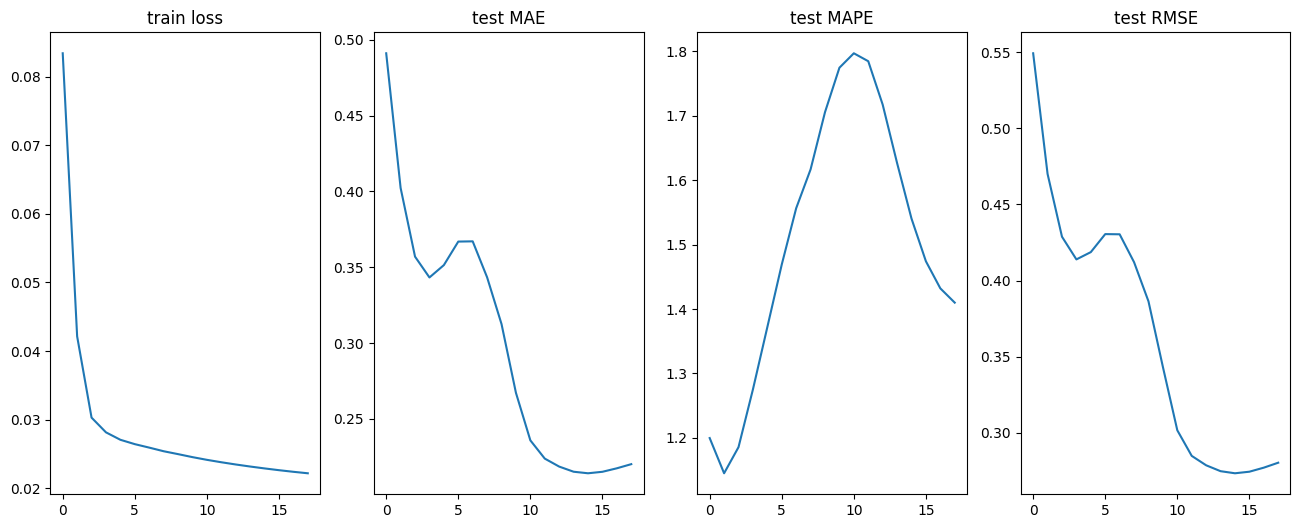

100%|██████████| 3/3 [00:41<00:00, 13.77s/it]


In [ ]:
epochs = 18

for e in tqdm(range(epochs)):
    train_loss = train(model, train_data, optimizer, loss_fn)
    loss_tottal.append(train_loss)

    preds, y = eval(model, test_data)
    mae.append(mean_absolute_error(y, preds))
    mape.append(mean_absolute_percentage_error(y, preds))
    rmse.append(root_mean_squared_error(y, preds))

    fig, ax = plt.subplots(1, 4, figsize=(16, 6))
    ax[0].plot(loss_tottal)
    ax[0].set_title('train loss')
    ax[1].plot(mae)
    ax[1].set_title('test MAE')
    ax[2].plot(mape)
    ax[2].set_title('test MAPE')
    ax[3].plot(rmse)
    ax[3].set_title('test RMSE')
    clear_output(wait=True)
    plt.show()


In [35]:
preds = []
model.eval()

with torch.no_grad():
    for seq, _ in test_data:
        preds.append(model(seq.to('cuda')).cpu())
   
true_predictions = scaler_y.inverse_transform(preds)

In [36]:
np.sqrt(np.mean((test_df[window_size:][cats_name].values - true_predictions) ** 2)), np.mean(np.abs(test_df[window_size:][cats_name].values - true_predictions))

(57.39856187941949, 38.42078434820365)

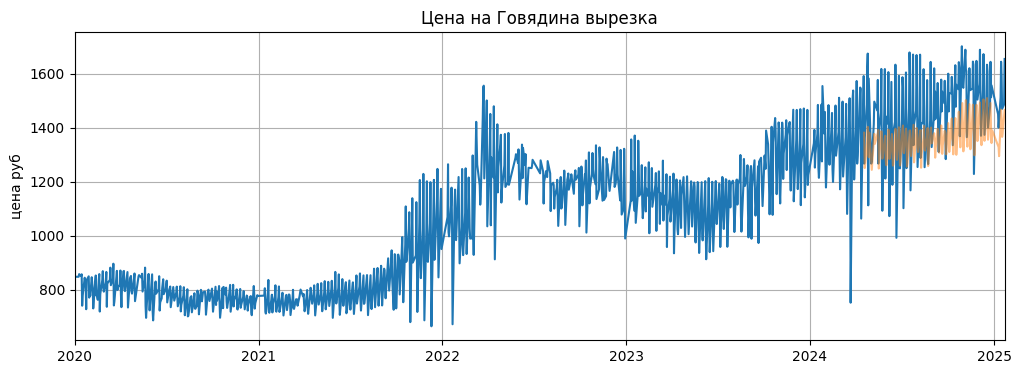

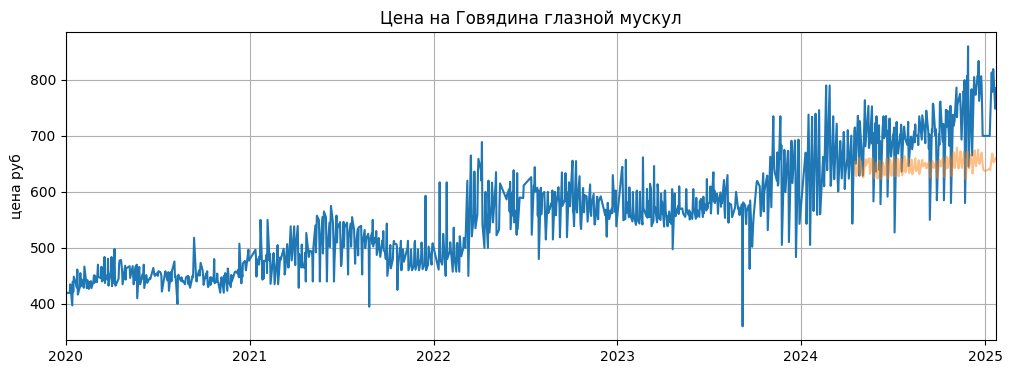

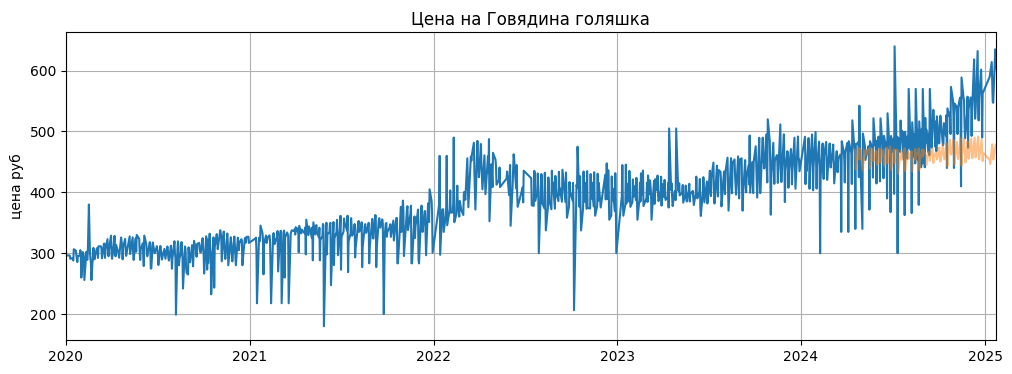

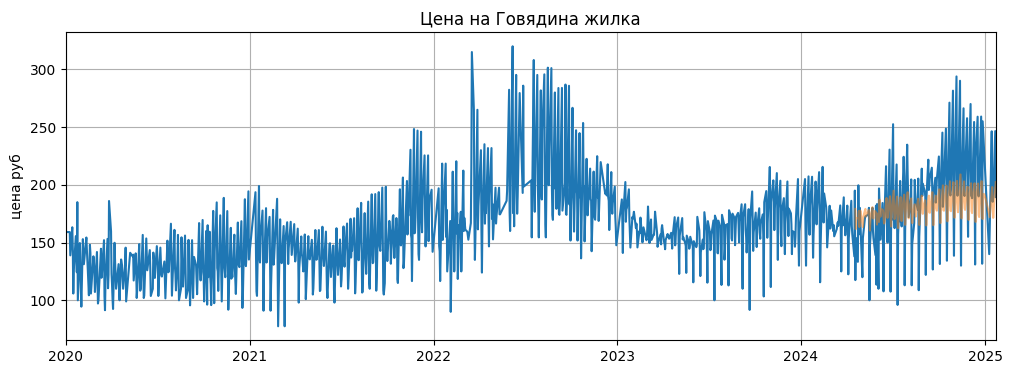

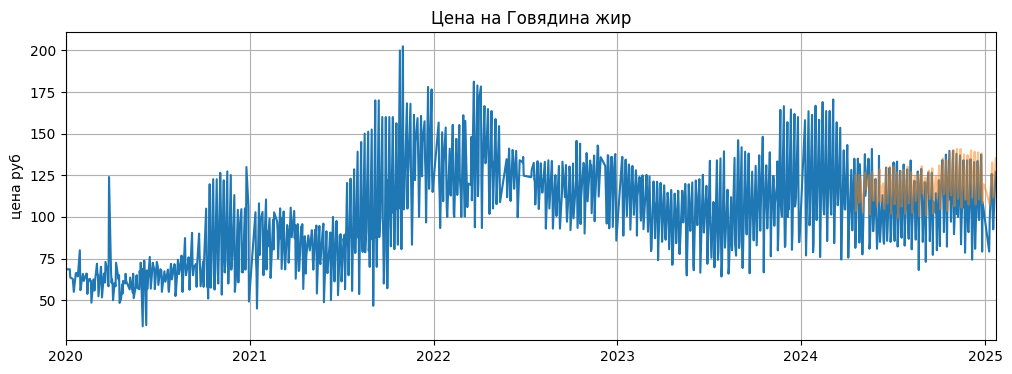

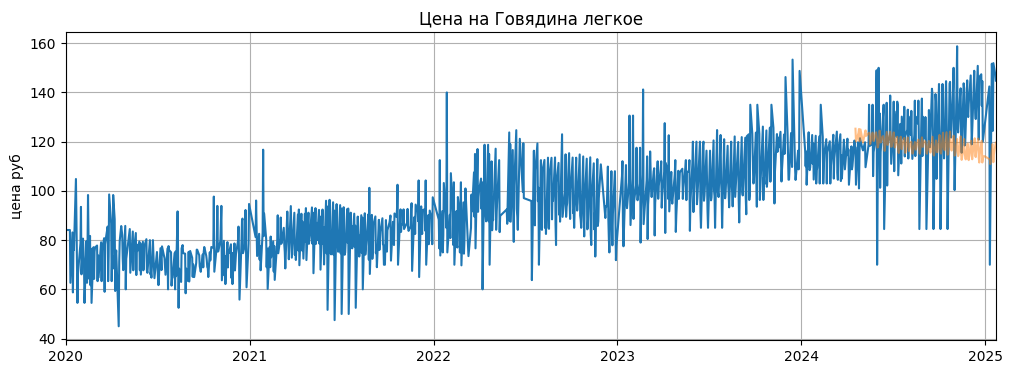

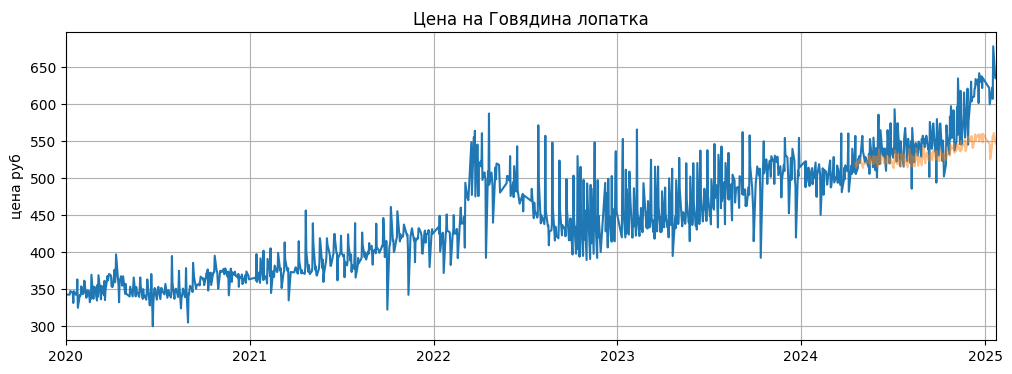

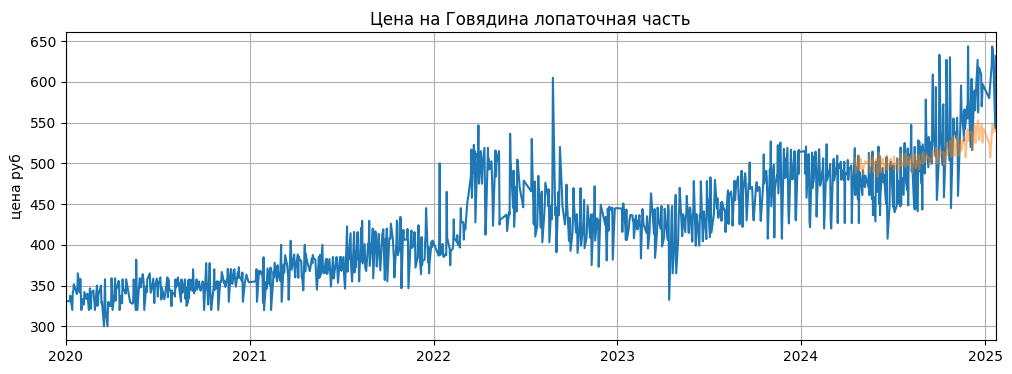

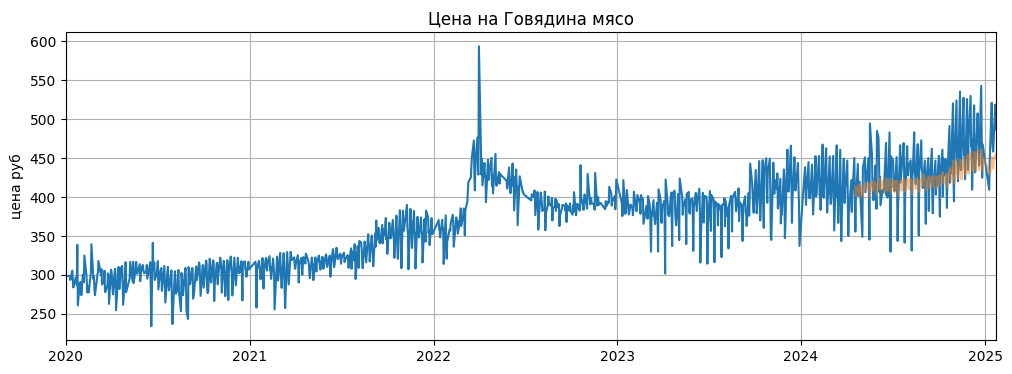

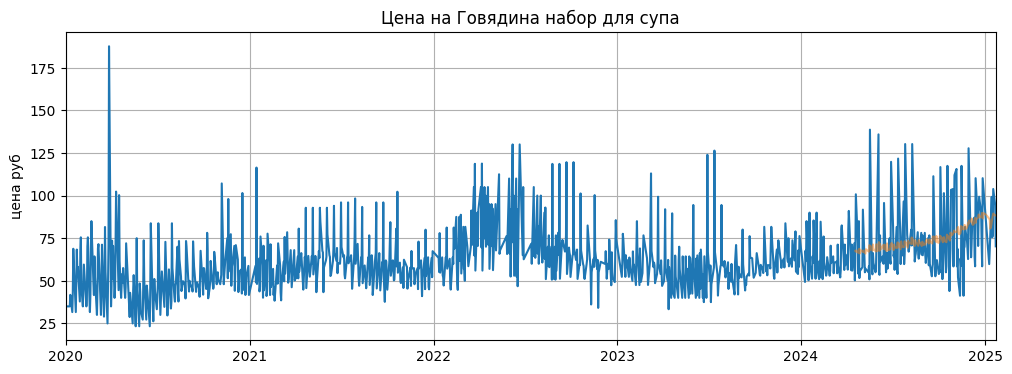

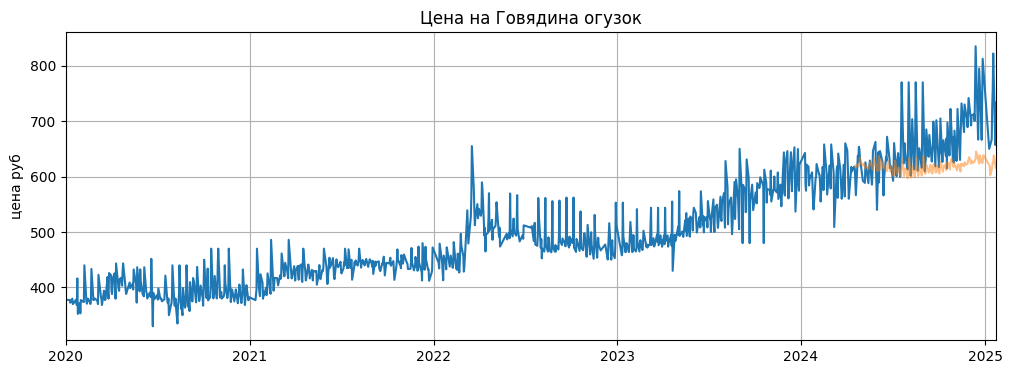

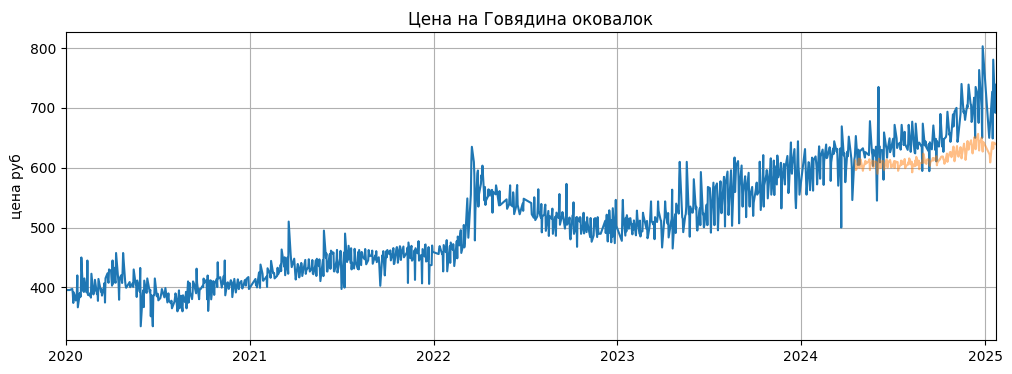

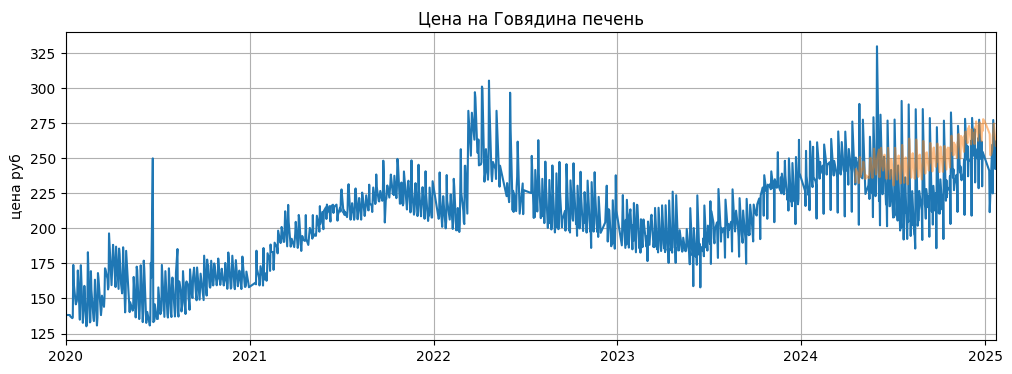

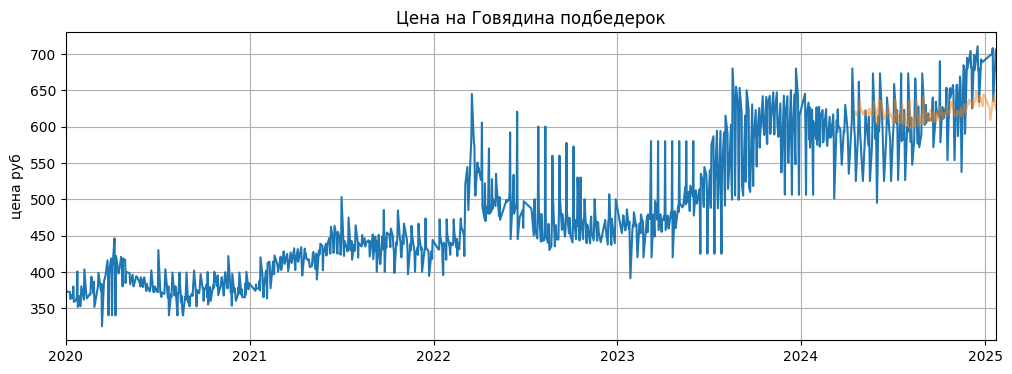

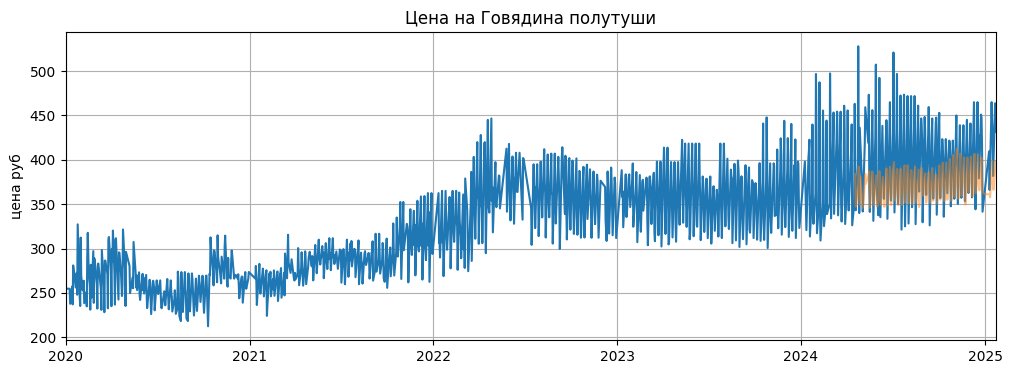

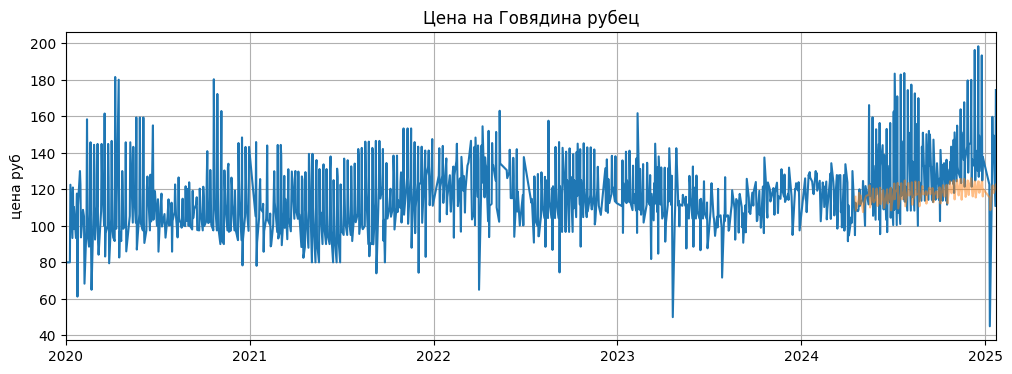

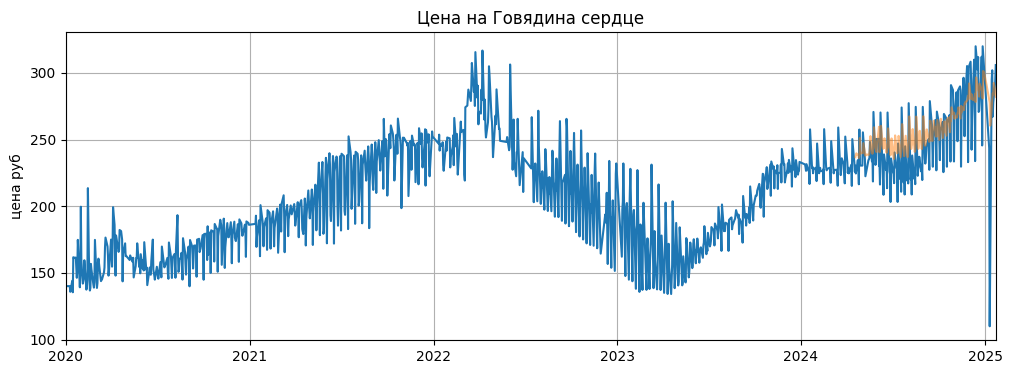

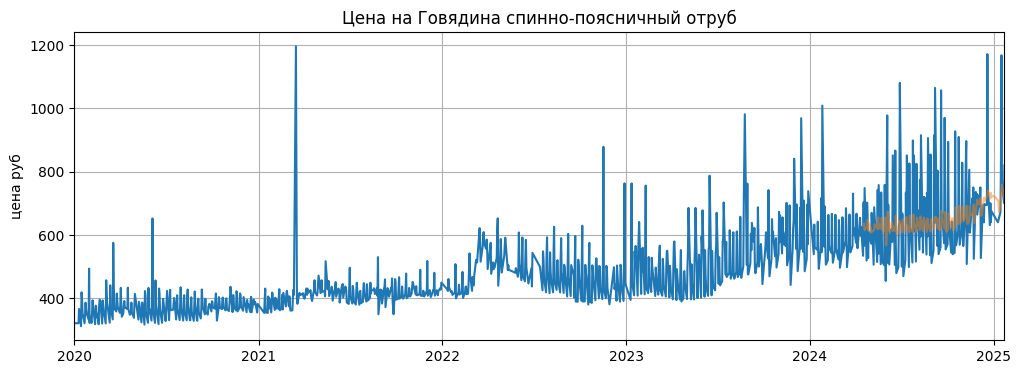

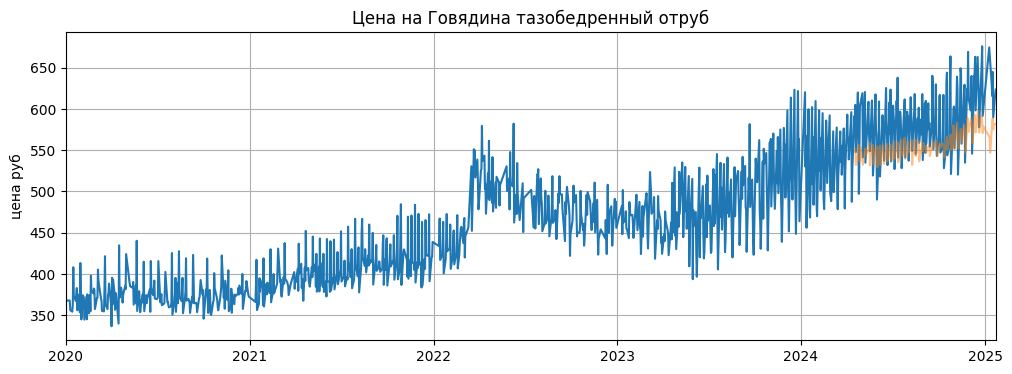

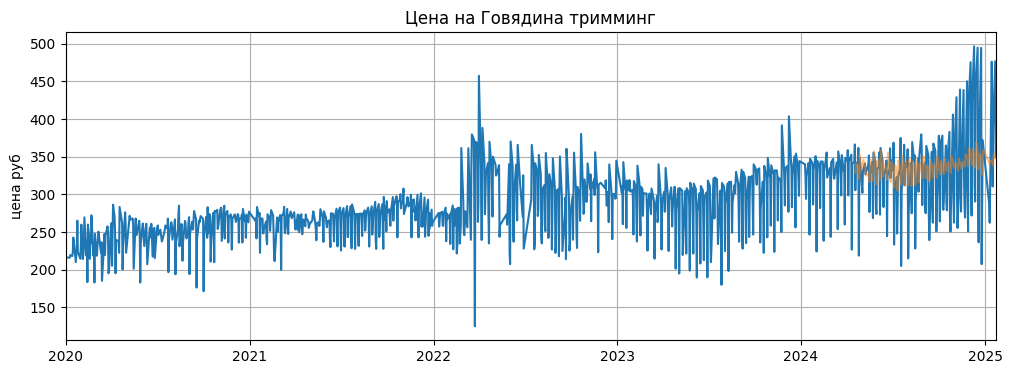

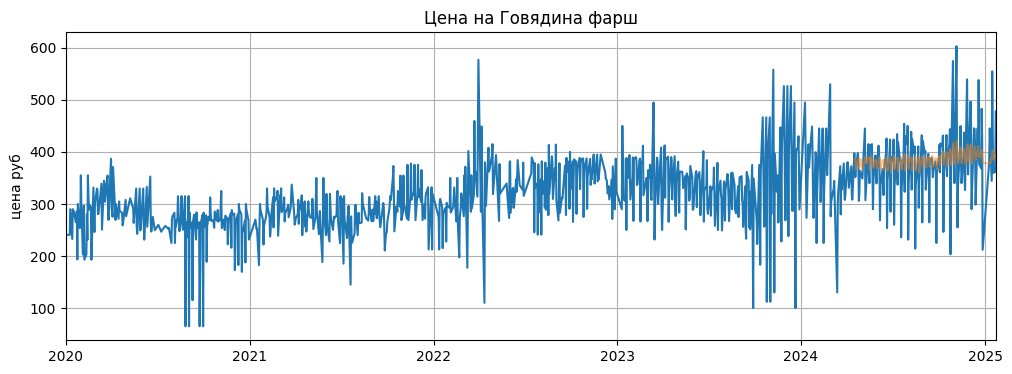

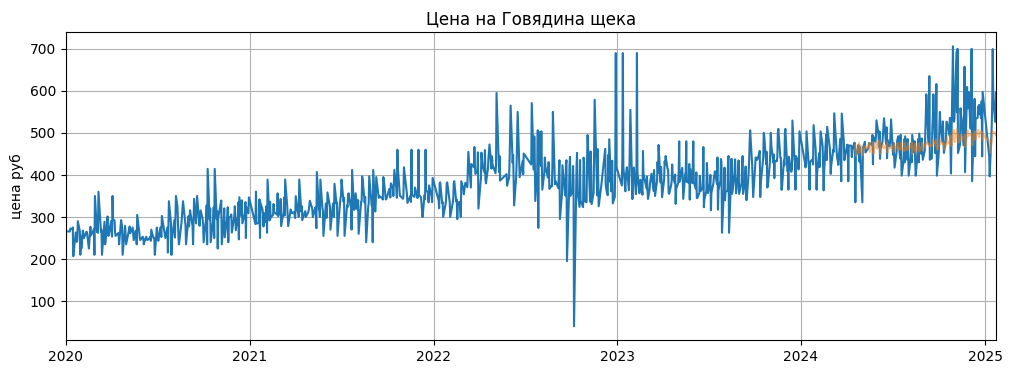

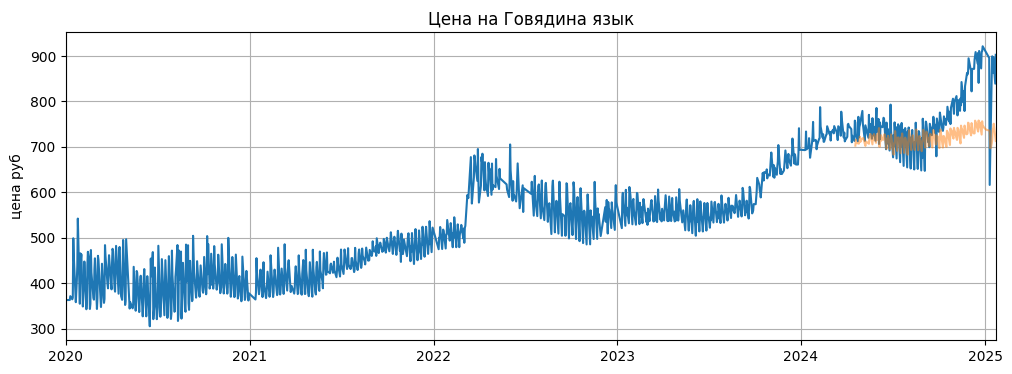

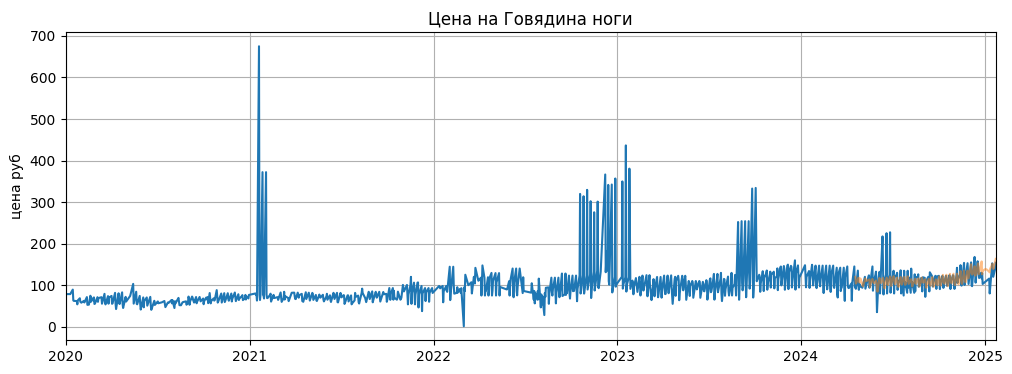

In [37]:
for i, cat in enumerate(cats_name):

    plt.figure(figsize = (12,4))
    plt.title(f'Цена на {cat}')
    plt.ylabel('цена руб')
    plt.grid(True)
    plt.autoscale(axis='x',tight=True)
    plt.plot(df.index, df[cat])
    sgift = len(test_df) - window_size
    plt.plot(test_df.index[-sgift:], true_predictions[:,i], alpha=0.5)
    plt.show()



LSTM может давать хорошие результаты, но при этом ее достаточно долго обучать и модель очень легко переобучить